# Exploratory Data Analysis: WatchNext

This notebook provides a comprehensive exploration of the MovieLens dataset used for the **WatchNext** recommendation engine. We analyze user behavior, movie popularity, genre distributions, and temporal trends to understand the underlying patterns in the data.

## 1. Setup and Data Loading

We begin by importing the necessary libraries and the modular EDA functions from the `watchnext` package.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root to sys.path to import watchnext
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from watchnext.data_loader import load_raw_data
from watchnext.eda import (
    preprocess_data, 
    calculate_metrics, 
    plot_rating_distribution,
    plot_ratings_per_user_movie,
    plot_interaction_density,
    plot_genre_cooccurrence,
    plot_temporal_trends,
    plot_tag_frequency
)

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
dataset = load_raw_data()
movies, ratings, ratings_with_movies = preprocess_data(dataset)

for name, df in dataset.items():
    print(f"{name:10} | Rows: {len(df):7} | Columns: {len(df.columns)}")

movies     | Rows:    9742 | Columns: 3
ratings    | Rows:  100836 | Columns: 4
links      | Rows:    9742 | Columns: 3
tags       | Rows:    3683 | Columns: 4


## 2. Global Dataset Statistics

Key metrics to understand the scale and sparsity of our recommendation problem.

In [3]:
metrics = calculate_metrics(dataset, movies, ratings)
pd.Series(metrics).to_frame("Value")

,Value
num_users,610.000
num_movies,9742.000
num_ratings,100836.000
ratings_sparsity,0.983
duplicate_user_movie_pairs,0.000
dangling_movie_ids,0.000
cold_start_users,0.000
cold_start_movies,7455.000
nulls_movies,0.000
nulls_ratings,0.000


## 3. Rating Distribution

How do users typically rate movies? Is there a bias towards higher or lower ratings?

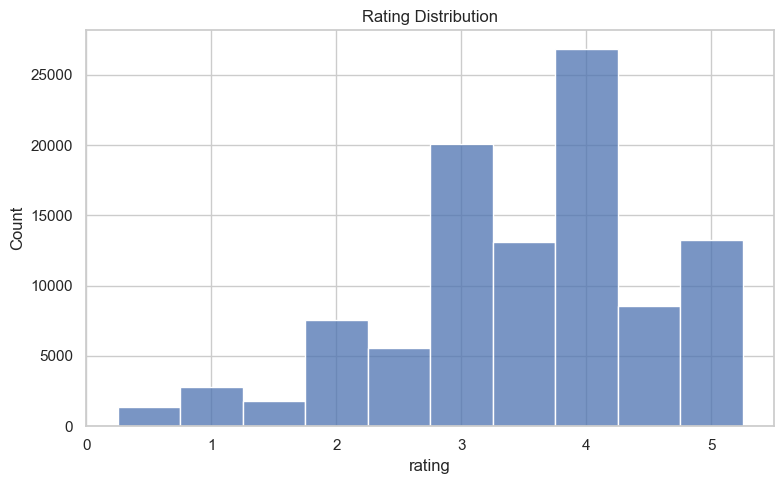

In [4]:
plot_rating_distribution(ratings)
plt.show()

## 4. User and Movie Activity

Visualizing the "Long Tail" effect. Most users rate only a few movies, and most movies have only a few ratings.

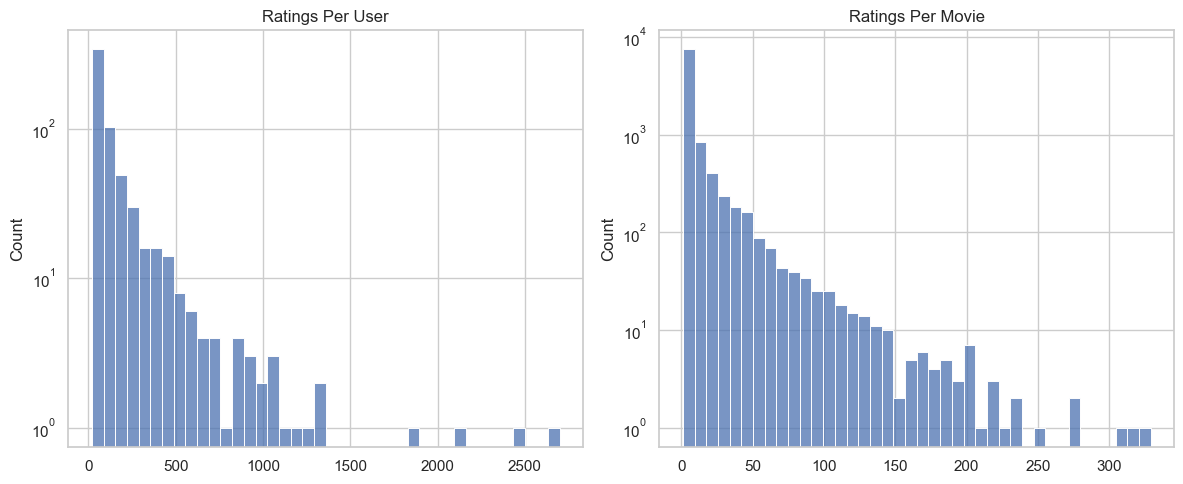

In [5]:
plot_ratings_per_user_movie(ratings)
plt.show()

## 5. Interaction Density

A heatmap showing interactions for a random sample of users and movies, highlighting the sparsity of the rating matrix.

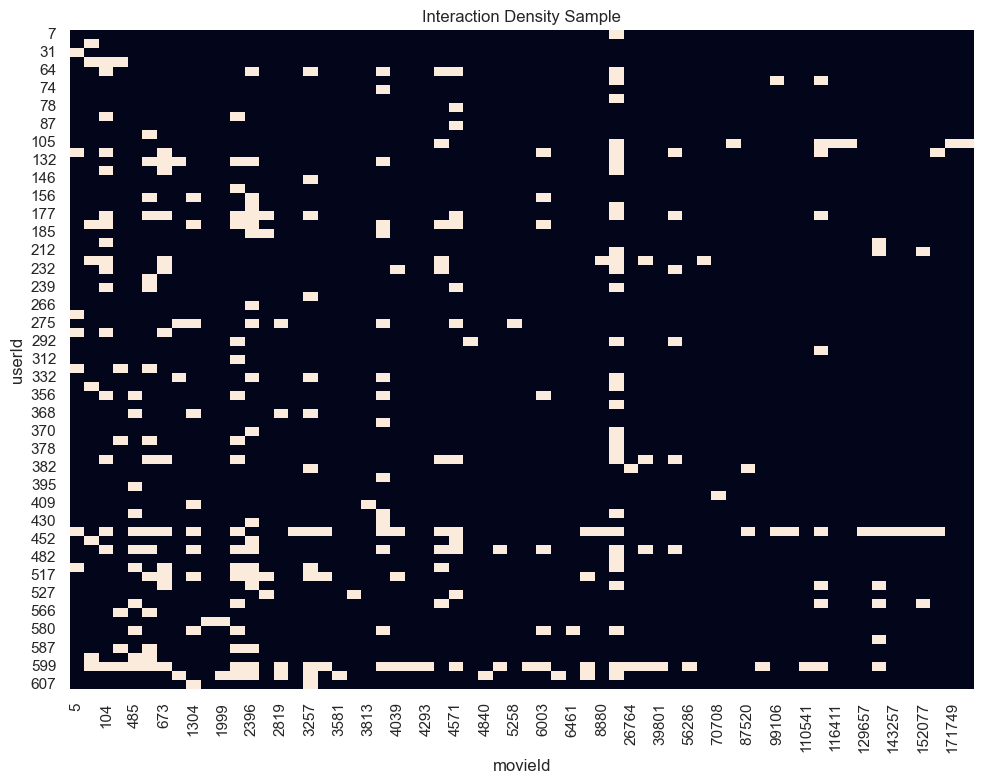

In [6]:
plot_interaction_density(ratings)
plt.show()

## 6. Content Analysis: Genres and Tags

Understanding the relationship between different genres and the most common tags assigned by users.

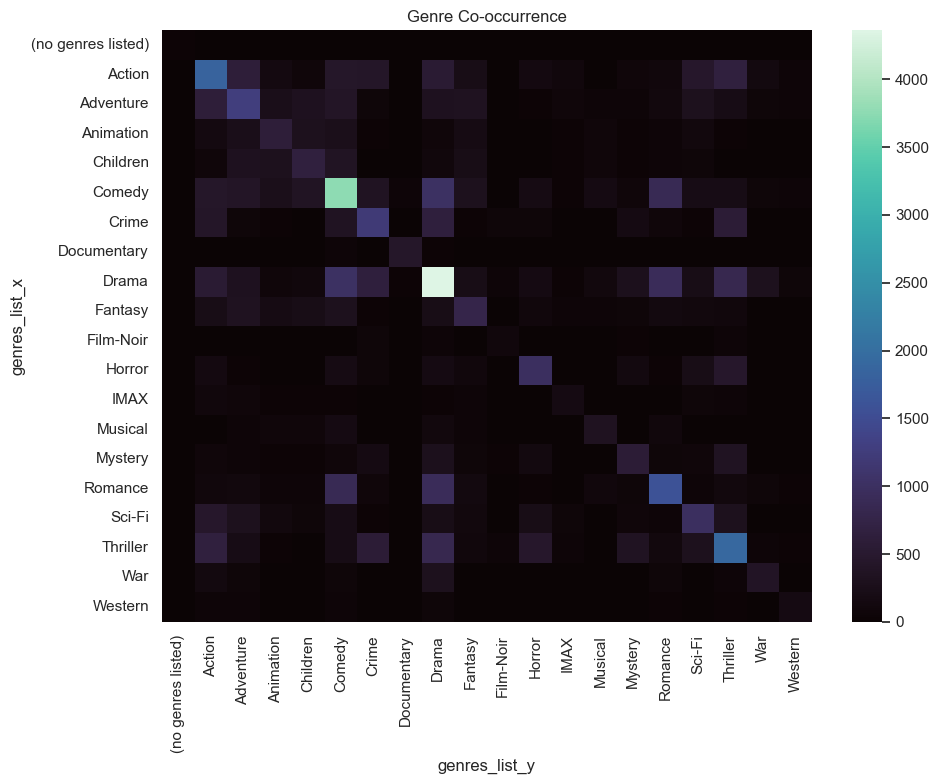

In [7]:
plot_genre_cooccurrence(movies)
plt.show()

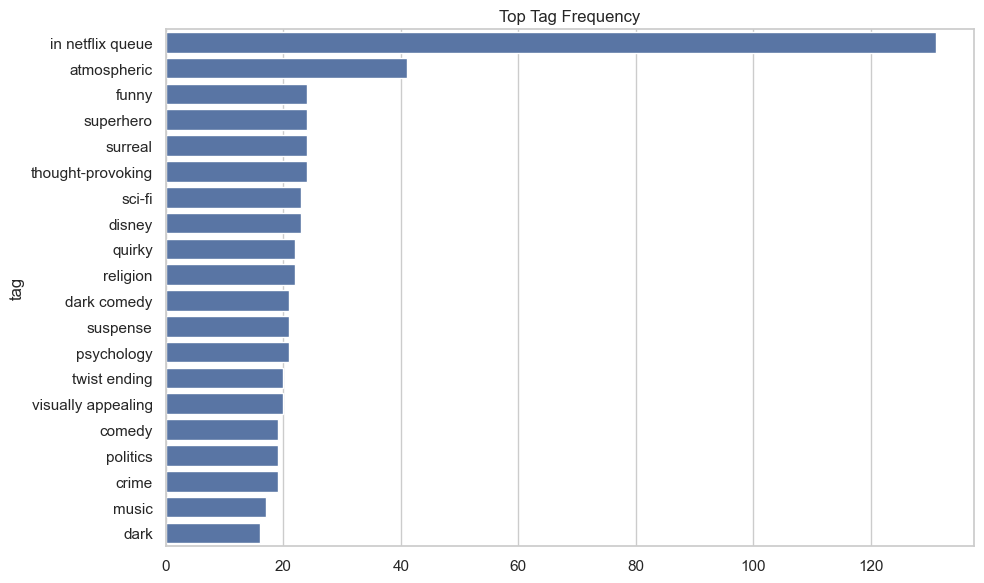

In [8]:
plot_tag_frequency(dataset["tags"])
plt.show()

## 7. Temporal Analysis

Analyzing how average ratings vary by the year they were given and by the movie's release year.

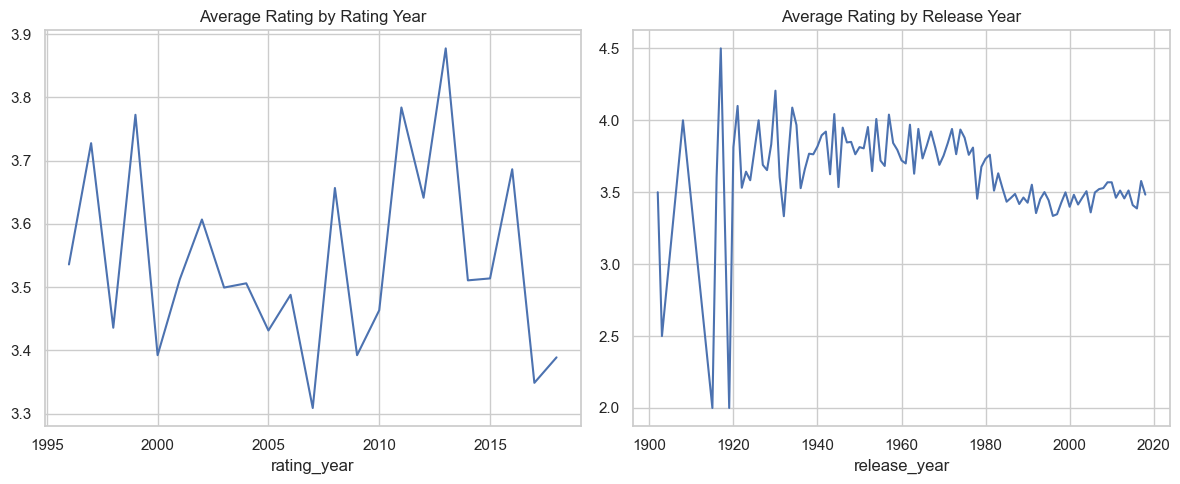

In [9]:
plot_temporal_trends(ratings, ratings_with_movies)
plt.show()

## Summary of Findings

1. **Sparsity**: The user-item matrix is extremely sparse, which is a common challenge for collaborative filtering.
2. **Long Tail**: Both users and movies follow a power-law distribution in terms of interaction frequency.
3. **Rating Bias**: Users tend to give higher ratings (3-4 range is most common), with very few ratings below 1.0.
4. **Genre Clusters**: Strong co-occurrences exist between genres like "Action" & "Adventure" or "Animation" & "Children".